# Notebook 4: XGBoost Classifier & Model Comparison

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (from Notebook 2)  
**Task:** Binary classification — predict whether a patient develops sepsis

---

## What this notebook does
1. Load the preprocessed train and test sets
2. Handle class imbalance using `scale_pos_weight`
3. Train a baseline XGBoost classifier
4. Tune hyperparameters using GridSearchCV
5. Evaluate — confusion matrix, ROC curve, feature importances
6. Compare Random Forest vs XGBoost side by side

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost              import XGBClassifier
from sklearn.ensemble     import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay
)

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Sepsis ML Project')

random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 3. Load Preprocessed Data

In [3]:
x_train = pd.read_csv(data_dir / 'X_train.csv', index_col='Patient_ID')
x_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col='Patient_ID')
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col='Patient_ID').squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col='Patient_ID').squeeze()

print(f'Training set : {x_train.shape[0]} patients, {x_train.shape[1]} features')
print(f'Test set     : {x_test.shape[0]} patients, {x_test.shape[1]} features')
print(f'Sepsis rate  — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%')

Training set : 3999 patients, 23 features
Test set     : 1000 patients, 23 features
Sepsis rate  — train: 7.3%  |  test: 7.3%


## 4. How XGBoost Works

XGBoost (Extreme Gradient Boosting) is a **boosting** algorithm. Unlike Random Forest which builds all trees independently and averages them, XGBoost builds trees **sequentially** — each new tree focuses on correcting the mistakes made by all previous trees.

After each tree is added, the residual errors (the cases the model got wrong) are upweighted, so the next tree pays more attention to those difficult cases. Over many iterations, the ensemble becomes very good at handling complex patterns.

**`scale_pos_weight`:** XGBoost does not have a `class_weight='balanced'` parameter like sklearn models. Instead, it uses `scale_pos_weight` — a single number that controls how much more weight is given to the positive class (sepsis). The standard formula is `count(non-sepsis) / count(sepsis)`. For example, if there are 4,500 non-sepsis and 500 sepsis patients in training, `scale_pos_weight = 9`. This tells XGBoost that a missed sepsis case costs 9 times more than a false alarm.

## 5. Handle Class Imbalance

In [4]:
n_negative       = (y_train == 0).sum()
n_positive       = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

print(f'Non-sepsis (train) : {n_negative}')
print(f'Sepsis     (train) : {n_positive}')
print(f'scale_pos_weight   : {scale_pos_weight:.2f}')

Non-sepsis (train) : 3709
Sepsis     (train) : 290
scale_pos_weight   : 12.79


## 6. Baseline XGBoost

In [5]:
baseline_xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=random_seed,
    verbosity=0
)
baseline_xgb.fit(x_train, y_train)

y_pred_base = baseline_xgb.predict(x_test)
y_prob_base = baseline_xgb.predict_proba(x_test)[:, 1]

print(f'F1 score : {f1_score(y_test, y_pred_base):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Non-Sepsis', 'Sepsis']))

F1 score : 0.1538
ROC-AUC  : 0.6977

              precision    recall  f1-score   support

  Non-Sepsis       0.93      0.98      0.95       927
      Sepsis       0.26      0.11      0.15        73

    accuracy                           0.91      1000
   macro avg       0.60      0.54      0.55      1000
weighted avg       0.88      0.91      0.90      1000



### 💡 What do these results actually mean?

Let's break down these numbers into simple terms:

* **The "Illusion" of 91% Accuracy:** At first glance, 91% sounds great! But because most patients *don't* have sepsis, the model can get a high score just by guessing "No Sepsis" almost every time.
* **Catching Sepsis (Recall = 0.11):** This is the most critical number. It means the model is currently only catching **11%** of the patients who actually develop sepsis. It's missing 89% of them, which is not good for a medical test.
* **False Alarms (Precision = 0.26):** When the model *does* ring the alarm and say "Sepsis!", it is only right about **26%** of the time. The rest are false alarms.
* **Overall Grade (F1 Score = 0.15):** This is a combined score of catching the illness and avoiding false alarms. A score of 0.15 is quite low, showing the model is struggling heavily right now.
* **ROC-AUC (0.69):** Think of this as the model's ability to rank a sick patient higher than a healthy patient. 0.5 is a coin flip, and 1.0 is perfect. At 0.69, it's better than guessing, but definitely needs improvement through tuning!

## 7. Hyperparameter Tuning — GridSearchCV

We use GridSearchCV with 5-fold stratified cross-validation, optimising for F1 score — the same setup as Notebook 3. This makes the two models directly comparable.

| Hyperparameter | Values Tested | What it controls |
|---|---|---|
| `n_estimators` | 100, 200 | Number of boosting rounds (trees) |
| `max_depth` | 3, 5, 7 | Maximum depth of each tree — deeper trees learn more complex patterns but risk overfitting |
| `learning_rate` | 0.05, 0.1 | How much each new tree contributes — smaller rates are more conservative and usually more accurate |
| `subsample` | 0.8, 1.0 | Fraction of training patients used per tree — values below 1.0 add randomness and reduce overfitting |

In [6]:
param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=random_seed,
    verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

grid_search = GridSearchCV(
    estimator=xgb, param_grid=param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)
grid_search.fit(x_train, y_train)

print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1      : 0.3110


## 8. Evaluate the Best Model

In [7]:
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(x_test)
y_prob = best_xgb.predict_proba(x_test)[:, 1]

print(f'F1 score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-Sepsis', 'Sepsis']))

F1 score : 0.2581
ROC-AUC  : 0.6999

              precision    recall  f1-score   support

  Non-Sepsis       0.94      0.93      0.94       927
      Sepsis       0.24      0.27      0.26        73

    accuracy                           0.89      1000
   macro avg       0.59      0.60      0.60      1000
weighted avg       0.89      0.89      0.89      1000



### 💡 Interpreting the Tuned Model's Results

Let's look at how our model improved after tuning its settings:

* **Catching Sepsis (Recall = 0.27):** This is the biggest improvement! The baseline model only caught 11% of sepsis cases. The tuned model now catches **27%**. While it's a step in the right direction, missing 73% of actual sepsis cases means it's still not ready for a real hospital setting.
* **False Alarms (Precision = 0.24):** This dropped slightly (from 26%). When the model rings the sepsis alarm, it's right about **24%** of the time. We traded a few more false alarms to catch more actual sick patients.
* **Overall Grade (F1 Score = 0.26):** This combined score jumped from 0.15 to 0.26. It shows the tuning process definitely helped the model learn better patterns, even if the overall performance is still modest.
* **The Accuracy Trap (89%):** It still looks great at 89%, but remember, this is mostly just the model correctly identifying the healthy patients!

## 9. Confusion Matrix

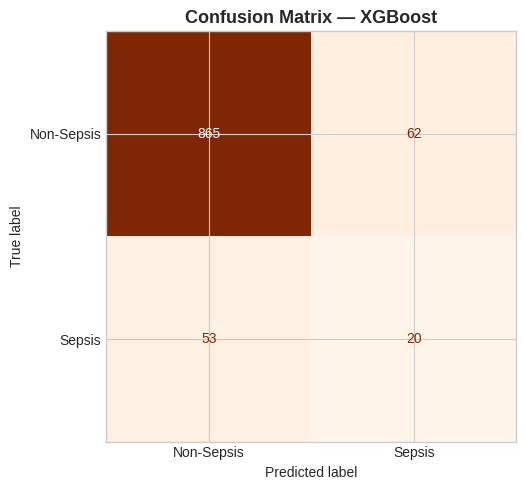

True Negatives  (correct non-sepsis) : 865
False Positives (false alarm)         : 62
False Negatives (missed sepsis)       : 53
True Positives  (caught sepsis)       : 20


In [8]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Non-Sepsis', 'Sepsis']).plot(
    ax=ax, colorbar=False, cmap='Oranges'
)
ax.set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'True Negatives  (correct non-sepsis) : {tn}')
print(f'False Positives (false alarm)         : {fp}')
print(f'False Negatives (missed sepsis)       : {fn}')
print(f'True Positives  (caught sepsis)       : {tp}')

## 10. ROC Curve

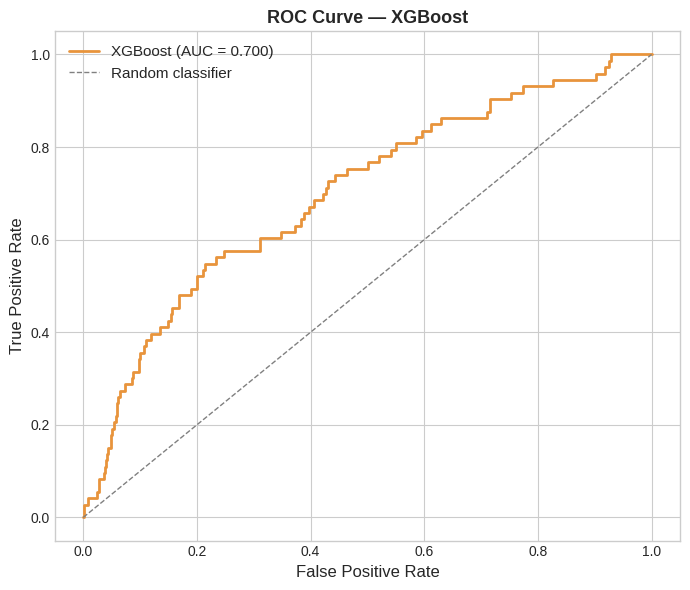

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc         = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#E8943C', linewidth=2,
        label=f'XGBoost (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 💡 Understanding the ROC Curve

Think of the ROC curve as a visual summary of the trade-off between **catching sick patients** (True Positives) and **raising false alarms** (False Positives) at various sensitivity levels.

*   **The Orange Line (Our Model):** This represents our XGBoost model. The closer this line bows toward the top-left corner, the better the model is at distinguishing between patients who will develop sepsis and those who won't.
*   **The Dotted Line:** This represents a useless model that just guesses randomly (a 50/50 coin flip).
*   **AUC (Area Under the Curve = 0.70):** This is the model's overall score for ranking patients. If you pick one random sick patient and one random healthy patient, our model has a 70% chance of correctly assigning a higher risk score to the sick patient. While 70% is noticeably better than a random guess (50%), a highly reliable medical test usually aims for 90% or higher.

## 11. Feature Importances

XGBoost computes feature importances based on how often each feature was used in a split and how much each split improved the model. Higher importance = the model relied on that feature more.

Comparing these to the Random Forest importances from Notebook 3 tells us whether both models agree on which clinical measurements are most predictive.

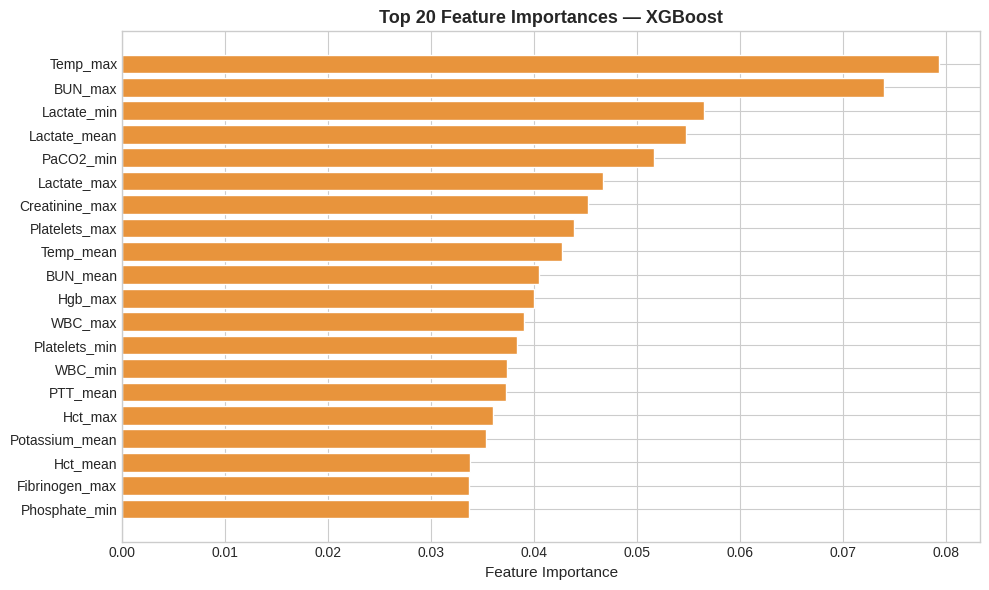

       feature  importance
      Temp_max    0.079379
       BUN_max    0.073974
   Lactate_min    0.056507
  Lactate_mean    0.054780
     PaCO2_min    0.051678
   Lactate_max    0.046696
Creatinine_max    0.045261
 Platelets_max    0.043934
     Temp_mean    0.042699
      BUN_mean    0.040476


In [10]:
feat_imp = pd.DataFrame({
    'feature'    : x_train.columns,
    'importance' : best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

top_n = min(20, len(feat_imp))
top   = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['feature'][::-1], top['importance'][::-1],
        color='#E8943C', edgecolor='white')
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importances — XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(feat_imp.head(10).to_string(index=False))

## 12. Model Comparison — Random Forest vs XGBoost

We re-train the best Random Forest here using the best hyperparameters found in Notebook 3, so both models are evaluated on exactly the same test set. Paste the best parameters from Notebook 3 into the cell below.

In [11]:
best_rf_params = {
    'n_estimators'      : 100,    # <-- update from Notebook 3
    'max_depth'         : 10,     # <-- update from Notebook 3
    'min_samples_split' : 5,      # <-- update from Notebook 3
    'max_features'      : 'sqrt'  # <-- update from Notebook 3
}

rf_compare = RandomForestClassifier(
    **best_rf_params, class_weight='balanced', random_state=random_seed
)
rf_compare.fit(x_train, y_train)

y_pred_rf = rf_compare.predict(x_test)
y_prob_rf = rf_compare.predict_proba(x_test)[:, 1]

rf_f1  = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

xgb_f1  = f1_score(y_test, y_pred)
xgb_auc = roc_auc_score(y_test, y_prob)

from sklearn.metrics import precision_score, recall_score
comparison_df = pd.DataFrame({
    'F1 Score'  : [rf_f1,                                           xgb_f1],
    'ROC-AUC'   : [rf_auc,                                          xgb_auc],
    'Precision' : [precision_score(y_test, y_pred_rf),              precision_score(y_test, y_pred)],
    'Recall'    : [recall_score(y_test, y_pred_rf),                 recall_score(y_test, y_pred)]
}, index=['Random Forest', 'XGBoost']).round(4)

print(comparison_df.to_string())
print()
print(f'Best model by F1 : {comparison_df["F1 Score"].idxmax()}')

               F1 Score  ROC-AUC  Precision  Recall
Random Forest    0.0879   0.6965     0.2222  0.0548
XGBoost          0.2581   0.6999     0.2439  0.2740

Best model by F1 : XGBoost


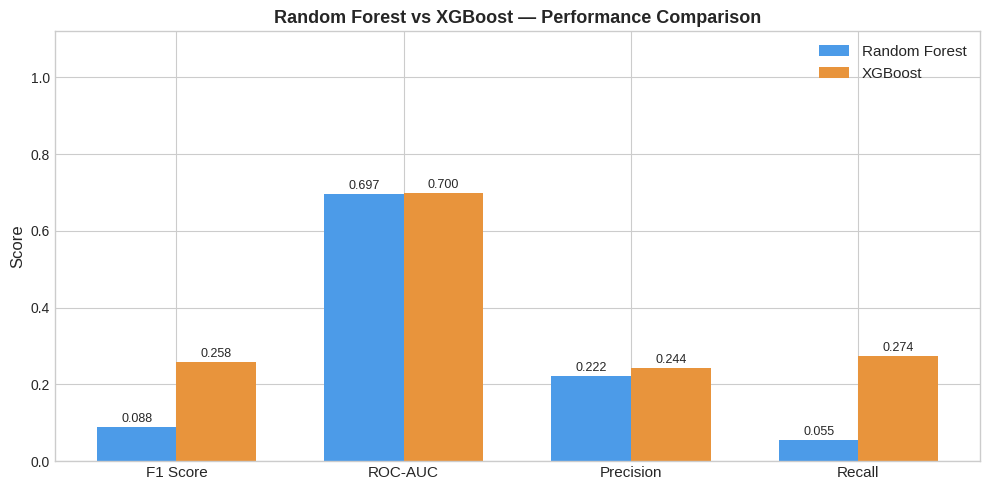

In [12]:
metrics    = ['F1 Score', 'ROC-AUC', 'Precision', 'Recall']
rf_scores  = comparison_df.loc['Random Forest'].values
xgb_scores = comparison_df.loc['XGBoost'].values

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_rf  = ax.bar(x - width/2, rf_scores,  width, label='Random Forest', color='#4C9BE8')
bars_xgb = ax.bar(x + width/2, xgb_scores, width, label='XGBoost',       color='#E8943C')

for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_xgb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Random Forest vs XGBoost — Performance Comparison',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

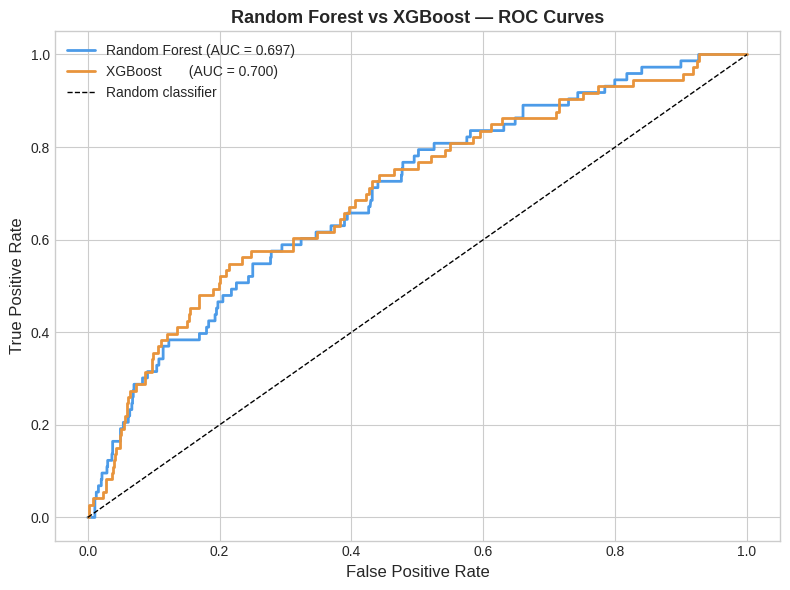

In [13]:
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_rf,  tpr_rf,  color='#4C9BE8', linewidth=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
ax.plot(fpr_xgb, tpr_xgb, color='#E8943C', linewidth=2, label=f'XGBoost       (AUC = {xgb_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('Random Forest vs XGBoost — ROC Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 13. Summary

### 💡 How can we improve these results?

Our current model is a good starting point, but it's still missing too many sepsis cases. Here are three ways we could make it better:

1.  **More Data (Especially Sick Patients):** Right now, only about 7% of our patients have sepsis. If we can train the model on a larger dataset that includes many more examples of patients with sepsis, it will have more opportunities to learn the complex warning signs. We could achieve this by including more actual sepsis cases from the original dataset when creating our subset, or by using techniques like SMOTE (Synthetic Minority Over-sampling Technique) to artificially generate more examples of the minority class.
2.  **Better Medical Information:** We could give the model more clues. Including things like a patient's past medical history, specific medications they are taking, or more frequent lab test results could help the model spot subtle changes earlier.
3.  **Advanced AI Models:** While XGBoost is powerful, we could try even more advanced techniques, like deep learning (neural networks), which are sometimes better at finding hidden patterns in large amounts of messy medical data over time.

In [16]:
winner = comparison_df['F1 Score'].idxmax()

print('XGBOOST — RESULTS')
print()
print(f'Best parameters : {grid_search.best_params_}')
print(f'F1 score        : {xgb_f1:.4f}')
print(f'ROC-AUC         : {xgb_auc:.4f}')
print(f'True positives  : {tp}')
print(f'False negatives : {fn}')
print()
print(comparison_df.to_string())
print()
print(f'Best model by F1 : {winner}')
print()
print('Pipeline complete.')

XGBOOST — RESULTS

Best parameters : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
F1 score        : 0.2581
ROC-AUC         : 0.6999
True positives  : 20
False negatives : 53

               F1 Score  ROC-AUC  Precision  Recall
Random Forest    0.0879   0.6965     0.2222  0.0548
XGBoost          0.2581   0.6999     0.2439  0.2740

Best model by F1 : XGBoost

Pipeline complete.
